# Will This Customer Purchase Your Product?

Analysis of ~12,000 online shopping sessions: how purchase (conversion) rates differ between
new and returning customers in the November-December peak season, how time spent in different
parts of the site relates, and the probability of reaching a sales target under an improved
conversion rate.

*Based on a DataCamp guided project; code tidied, results derived programmatically, and a
visualization added. Data adapted from the Online Shoppers Purchasing Intention dataset
(UCI Machine Learning Repository, DOI: 10.24432/C5F88Q).*

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the data
shopping_data = pd.read_csv("online_shopping_session_data.csv")
print(f"Sessions loaded: {shopping_data.shape[0]}")

# Drop rows with missing values in any affected column
nan_cols = shopping_data.columns[shopping_data.isna().any()]
shopping_data = shopping_data.dropna(axis=0, subset=nan_cols)
print(f"Sessions after dropping missing values: {shopping_data.shape[0]}")

Sessions loaded: 12055
Sessions after dropping missing values: 12054


## Purchase rates: new vs. returning customers (Nov-Dec)

In [2]:
# Filter to the November-December peak season
shopping_filtered = shopping_data[shopping_data["Month"].isin(["Nov", "Dec"])].copy()

# Give the purchase column meaningful labels
shopping_filtered["Purchase"] = shopping_filtered["Purchase"].map({0.0: "No", 1.0: "Yes"})

# Session and purchase counts per customer type
shopping_counts = shopping_filtered.groupby("CustomerType")["Purchase"].value_counts()

# Purchase rates per customer type
purchase_rates = {
    customer_type: shopping_counts[(customer_type, "Yes")] / shopping_counts[customer_type].sum()
    for customer_type in ["Returning_Customer", "New_Customer"]
}
for customer_type, rate in purchase_rates.items():
    print(f"{customer_type}: {rate:.1%}")

Returning_Customer: 19.6%
New_Customer: 27.3%


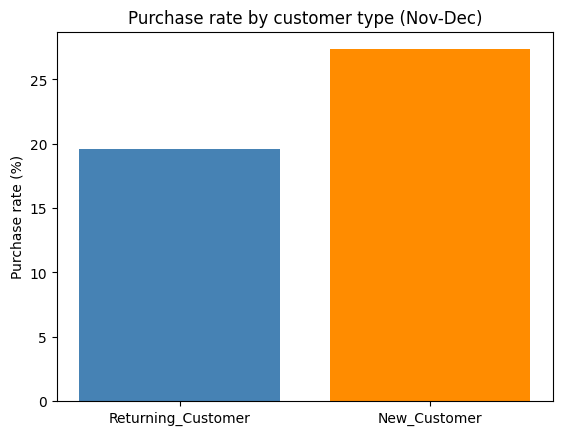

In [3]:
# Visualize the purchase rates
fig, ax = plt.subplots()
ax.bar(purchase_rates.keys(), [r * 100 for r in purchase_rates.values()], color=["steelblue", "darkorange"])
ax.set_title("Purchase rate by customer type (Nov-Dec)")
ax.set_ylabel("Purchase rate (%)")
plt.show()

## Which browsing durations move together?

In [4]:
# Correlation between time spent in different parts of the site
duration_cols = ["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration"]
shopping_corr_matrix = shopping_filtered[duration_cols].corr().round(3)
print(shopping_corr_matrix)

# Derive the strongest correlation pair programmatically
corr_pairs = shopping_corr_matrix.where(~np.eye(len(duration_cols), dtype=bool)).stack()
top_correlation = {"pair": corr_pairs.idxmax(), "correlation": round(corr_pairs.max(), 3)}
print(f"Strongest correlation: {top_correlation}")

                         Administrative_Duration  Informational_Duration  \
Administrative_Duration                    1.000                   0.245   
Informational_Duration                     0.245                   1.000   
ProductRelated_Duration                    0.390                   0.367   

                         ProductRelated_Duration  
Administrative_Duration                    0.390  
Informational_Duration                     0.367  
ProductRelated_Duration                    1.000  
Strongest correlation: {'pair': ('Administrative_Duration', 'ProductRelated_Duration'), 'correlation': np.float64(0.39)}


## Probability of reaching a sales target

In [5]:
# Assume the returning-customer purchase rate improves by 15%
improved_rate = purchase_rates["Returning_Customer"] * 1.15
print(f"Improved returning-customer purchase rate: {improved_rate:.1%}")

# Probability of at least 100 sales out of 500 returning-customer sessions (binomial)
prob_at_least_100_sales = 1 - stats.binom.cdf(100, 500, improved_rate)
print(f"Probability of at least 100 sales in 500 sessions: {prob_at_least_100_sales:.1%}")

Improved returning-customer purchase rate: 22.5%
Probability of at least 100 sales in 500 sessions: 90.1%


### Key observations

- In the Nov-Dec peak season, new customers convert at a *higher* rate (~27%) than returning customers (~20%) in this dataset.
- Time spent on administrative pages correlates most strongly with time on product-related pages (r ≈ 0.39) - sessions that browse products also tend to interact with account/administrative pages.
- If the returning-customer purchase rate improved 15% (to ~22.5%), the probability of reaching at least 100 sales in 500 sessions would be ~90%.